# Plate ID Assignment: Inline Point Data

When working with paleogeographic reconstructions, it's common to have a list of modern-day coordinates (longitude, latitude). For example, fossil find locations, volcanic hotspots, or sampling stations.

If we want to **reconstruct these points to past geological times**, we first need to know:

1. Which tectonic plate each point belongs to.
2. The valid time range for that point’s position.

This tutorial shows how to:
- Read a set of point data that's defined within the notebook (Python list of dictionaries)
- Assign plate IDs and valid time periods to those points.
- Save the results into a GPML file that you can open in `pyGPlates`.

### Setup

Let's begin by importing the required packages!

In [19]:
# Ensure you have the required packages installed:
# Run `pip install pygplates gplately` in your terminal if you haven't done so already.

from plate_model_manager import PlateModelManager
import pygplates
import matplotlib.pyplot as plt
import gplately
import cartopy.crs as ccrs

We need two things before we get started:

- A rotation model → tells the software how plates have moved over geological time.

- Static polygons → tells it which plate each location belongs to today (present-day geometry).

Without these two, the `GPlately` has no idea how your locations relate to plates, or how to move them backwards in time.

> NOTE: Using `PlateModelManager` means you don’t need to hardcode file paths, but you can also manually specify the .rot & .gpml filepaths if needed!

In [20]:
# Create a Plate Model Manager
pm_manager = PlateModelManager()

# Load & download model data into the path specified by 'data_dir'
# To load a specific model, you can specify the model name
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# Get the rotation model and static polygons from the loaded model
# Alternatively, specify the paths directly if you have them
rotation_model = muller2019_model.get_rotation_model()
static_polygons_filename = muller2019_model.get_static_polygons()

# Define output filename
output_points_filename = '../../data/cities_with_plate_ids.gpml'

Next, we create a Python list of dictionaries, where each dictionary stores:

- name → the name of the city (this will be useful for identifying it later in our results).

- lon → longitude in decimal degrees.

- lat → latitude in decimal degrees.

> NOTE: You can also import this data from a file (eg. .csv or .txt)!

After defining our XY data, we loop through each city and:

- Create a `PointOnSphere` i.e. pyGPlates’ internal representation of a geographic point.

- Create a Feature i.e. a pyGPlates object that can store geometry plus metadata.

- We attach the point geometry & the city name.

- Add the feature to a list (`point_features`).

This essentially transforms our simple Python data into something pyGPlates can understand and process.

In [21]:
# Define XY data for cities
# These are just example coordinates; you can replace them with your own data.
cities = [
    {'name': 'Sydney', 'lon': 151.2093, 'lat': -33.8688},
    {'name': 'London', 'lon': -0.1278, 'lat': 51.5074},
    {'name': 'Tokyo', 'lon': 139.6917, 'lat': 35.6895},
    {'name': 'Cairo', 'lon': 31.2357, 'lat': 30.0444},
    {'name': 'Rio de Janeiro', 'lon': -43.1729, 'lat': -22.9068},
    {'name': 'New York', 'lon': -74.0060, 'lat': 40.7128}
]

point_features = []

for city in cities:
    point = pygplates.PointOnSphere(city['lat'], city['lon'])  # lat/lon order for pyGPlates
    feature = pygplates.Feature()
    feature.set_geometry(point)

    # Store the city name as a property so it’s preserved in GPML
    feature.set_name(city['name'])

    # Add the feature to the list
    point_features.append(feature)

### Assigning Plate IDs!

Now, we assign plate IDs to these points! Here's how it works:

- The function compares each city’s location (`point_features`) with the static polygons (present-day plate boundaries).

- It uses the rotation model to understand how these polygons relate to plates in the reconstruction.

- `properties_to_copy` tells pyGPlates which extra attributes to attach to each feature — in this case, both the plate ID and valid time period.

The result is a new list of features (`assigned_features`) with plate information attached, ready for reconstruction or export.

In [22]:
# Use the static polygons to assign plate IDs and valid time periods.
# Each point feature is partitioned into one of the static polygons and assigned its
# reconstruction plate ID and valid time period.

assigned_features = pygplates.partition_into_plates(
    static_polygons_filename,
    rotation_model,
    point_features,
    properties_to_copy=[
        pygplates.PartitionProperty.reconstruction_plate_id,
        pygplates.PartitionProperty.valid_time_period
    ]
)

Next, we:

- Wrap the assigned features into a `FeatureCollection` (this is pyGPlates’ container for storing multiple features together).

- Write the collection to a `GPML` file using .write(). GPML (GPlates Markup Language) is the format GPlates uses to store reconstructed geometries and metadata.

Once saved, you can open this .gpml file in `GPlately` to visualise the cities with their assigned plate IDs and time periods!

In [23]:
# Save the assigned features to a new GPML file
feature_collection = pygplates.FeatureCollection(assigned_features)
feature_collection.write(output_points_filename)

print(f"Saved results to {output_points_filename}")

Saved results to ../../data/cities_with_plate_ids.gpml


### Visualising the Effect of Plate IDs

Now let's see what difference assigning plate IDs actually makes! We'll reconstruct our cities to 100 million years ago and compare:

1. Without plate IDs: Points stay in their modern positions (incorrect!)

2. With plate IDs: Points move with their tectonic plates (geologically accurate!)

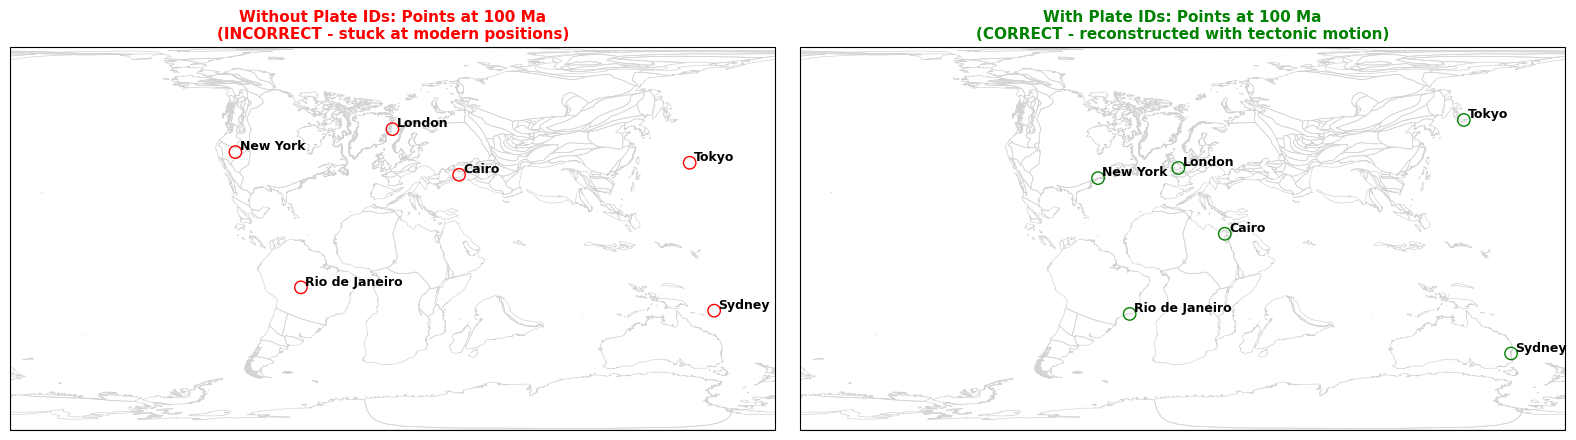

In [26]:
# --------------------------------------------------
# Reconstruct at chosen geological time
# --------------------------------------------------
reconstruction_time = 100   # Ma

# Create a GPlately Reconstruction & PlotTopologies object for plotting
model = gplately.PlateReconstruction(rotation_model, static_polygons_filename)
gplot = gplately.PlotTopologies(model, time=reconstruction_time)

# Load features for both cases
original_features = pygplates.FeatureCollection(point_features)
reconstructed_original_features = model.reconstruct(original_features, to_time=reconstruction_time)

assigned_feature_collection = pygplates.FeatureCollection(output_points_filename)
reconstructed_assigned_features = model.reconstruct(assigned_feature_collection, to_time=reconstruction_time)

# Coastlines
coastlines = muller2019_model.get_layer("Coastlines")
reconstructed_coastlines = model.reconstruct(coastlines, to_time=reconstruction_time)

# --------------------------------------------------
# Plot comparison
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8),
                               subplot_kw={"projection": ccrs.PlateCarree()})

# --- Left plot: Without plate IDs ---
gplot.plot_feature(ax1, reconstructed_coastlines, color="lightgray", linewidth=0.5)
gplot.plot_feature(ax1, reconstructed_original_features, color="red", markersize=80, marker="o")

# Add point labels
for feature in reconstructed_original_features:
    geometry = feature.get_reconstructed_geometry()
    lat, lon = geometry.to_lat_lon()
    name = feature.get_feature().get_name()
    ax1.text(lon + 2, lat + 1, name, fontsize=9, fontweight="bold", transform=ccrs.PlateCarree())

ax1.set_title(f"Without Plate IDs: Points at {reconstruction_time} Ma\n(INCORRECT - stuck at modern positions)",
              fontsize=11, fontweight="bold", color="red")
ax1.set_global()

# --- Right plot: With plate IDs ---
gplot.plot_feature(ax2, reconstructed_coastlines, color="lightgray", linewidth=0.5)
gplot.plot_feature(ax2, reconstructed_assigned_features, color="green", markersize=80, marker="o")

# Add point labels
for feature in reconstructed_assigned_features:
    geometry = feature.get_reconstructed_geometry()
    lat, lon = geometry.to_lat_lon()
    name = feature.get_feature().get_name()
    ax2.text(lon + 2, lat + 1, name, fontsize=9, fontweight="bold", transform=ccrs.PlateCarree())

ax2.set_title(f"With Plate IDs: Points at {reconstruction_time} Ma\n(CORRECT - reconstructed with tectonic motion)",
              fontsize=11, fontweight="bold", color="green")
ax2.set_global()

plt.tight_layout()
plt.show()

This code block provides a side-by-side comparison of present vs. past positions, together with the displacement distance. This makes it clear how assigning plate IDs changes the reconstruction, ensuring each point follows the correct tectonic plate through time.

For each city in the dataset:

1. Modern position: The present-day latitude and longitude are printed.

2. Reconstructed position: The city’s position is reconstructed at the target geological age, after assigning the appropriate plate ID.

3. Movement distance: The great-circle distance (shortest path between two points on the surface of a sphere) between the modern and reconstructed coordinates is calculated, showing how far the location has shifted due to plate motion.

4. Plate assignment: The plate ID to which the city belongs is displayed, confirming which tectonic plate controlled its movement.

In [25]:
# Print the coordinate changes for comparison
print(f"\nCoordinate comparison at {reconstruction_time} Ma:")
print("=" * 60)

for i, city in enumerate(cities):
    # Modern coordinates
    modern_lon, modern_lat = city['lon'], city['lat']
    city_name = city['name']
    
    # Find the corresponding reconstructed feature
    for feature in reconstructed_assigned_features:
        if feature.get_feature().get_name() == city_name:
            reconstructed_geometry = feature.get_reconstructed_geometry()
            recon_lat, recon_lon = reconstructed_geometry.to_lat_lon()
            
            print(f"{city_name}:")
            print(f"  Modern position:        {modern_lon:8.2f}°E, {modern_lat:7.2f}°N")
            print(f"  Reconstructed position: {recon_lon:8.2f}°E, {recon_lat:7.2f}°N")
            
            # Calculate movement distance
            distance_moved = pygplates.GeometryOnSphere.distance(
                pygplates.PointOnSphere(modern_lat, modern_lon),
                pygplates.PointOnSphere(recon_lat, recon_lon)
            ) * pygplates.Earth.mean_radius_in_kms
            
            print(f"  Distance moved:         {distance_moved:8.0f} km")
            
            # Get plate ID information
            plate_id = feature.get_feature().get_reconstruction_plate_id()
            print(f"  Assigned to plate:      {plate_id}")
            print("-" * 40)
            break


Coordinate comparison at 100 Ma:
Sydney:
  Modern position:          151.21°E,  -33.87°N
  Reconstructed position:   154.49°E,  -54.00°N
  Distance moved:             2253 km
  Assigned to plate:      801
----------------------------------------
London:
  Modern position:           -0.13°E,   51.51°N
  Reconstructed position:    -2.00°E,   33.24°N
  Distance moved:             2037 km
  Assigned to plate:      315
----------------------------------------
Tokyo:
  Modern position:          139.69°E,   35.69°N
  Reconstructed position:   132.28°E,   55.81°N
  Distance moved:             2307 km
  Assigned to plate:      629
----------------------------------------
Cairo:
  Modern position:           31.24°E,   30.04°N
  Reconstructed position:    19.83°E,    2.29°N
  Distance moved:             3312 km
  Assigned to plate:      715
----------------------------------------
Rio de Janeiro:
  Modern position:          -43.17°E,  -22.91°N
  Reconstructed position:   -24.92°E,  -35.40°N
  Di